# Exploratory Data Analysis — Multimodal Biometric Dataset

This notebook explores the [Kaggle Multimodal Iris + Fingerprint Biometric Data](https://www.kaggle.com/datasets/ninadmehendale/multimodal-iris-fingerprint-biometric-data) used in this project.

**What we'll look at:**
1. Dataset structure & file counts
2. Sample images from each modality
3. Class (subject) distribution
4. Modality completeness per subject
5. Image size & channel statistics

In [1]:
import os
import sys
from pathlib import Path
from collections import Counter

import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import numpy as np

# Project paths
PROJECT_ROOT = Path("..").resolve()
RAW_DIR = PROJECT_ROOT / "data" / "raw"
PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"

MODALITIES = ["iris_left", "iris_right", "fingerprint"]

print(f"Raw data dir: {RAW_DIR}")
print(f"Exists: {RAW_DIR.exists()}")

Raw data dir: /Users/anand.kummari/personal/bosch/multimodal-biometric-mlops/data/raw
Exists: True


## 1. Dataset Structure

Each subject folder contains sub-folders for `iris_left`, `iris_right`, and `fingerprint`.

In [2]:
# Scan dataset structure
subjects = sorted([d.name for d in RAW_DIR.iterdir() if d.is_dir()])
print(f"Total subjects: {len(subjects)}")
print(f"First 5: {subjects[:5]}")
print(f"Last 5:  {subjects[-5:]}")

# Count images per modality per subject
stats = {}
for subj in subjects:
    subj_dir = RAW_DIR / subj
    counts = {}
    for mod in MODALITIES:
        mod_dir = subj_dir / mod
        if mod_dir.exists():
            imgs = [f for f in mod_dir.iterdir() if f.suffix.lower() in (".bmp", ".png", ".jpg", ".jpeg")]
            counts[mod] = len(imgs)
        else:
            counts[mod] = 0
    stats[subj] = counts

# Summary table
print(f"\n{'Subject':<15} {'iris_left':>10} {'iris_right':>11} {'fingerprint':>12}")
print("-" * 50)
for subj in subjects[:5]:
    c = stats[subj]
    print(f"{subj:<15} {c['iris_left']:>10} {c['iris_right']:>11} {c['fingerprint']:>12}")
print("...")

total_images = sum(c[m] for c in stats.values() for m in MODALITIES)
print(f"\nTotal images across all subjects: {total_images}")

Total subjects: 45
First 5: ['subject_001', 'subject_002', 'subject_003', 'subject_004', 'subject_005']
Last 5:  ['subject_041', 'subject_042', 'subject_043', 'subject_044', 'subject_045']

Subject          iris_left  iris_right  fingerprint
--------------------------------------------------
subject_001              5           5           10
subject_002              5           5           10
subject_003              5           5           10
subject_004              5           5           10
subject_005              5           5           10
...

Total images across all subjects: 900


## 2. Sample Images

Let's visualize one sample from each modality for the first 3 subjects.

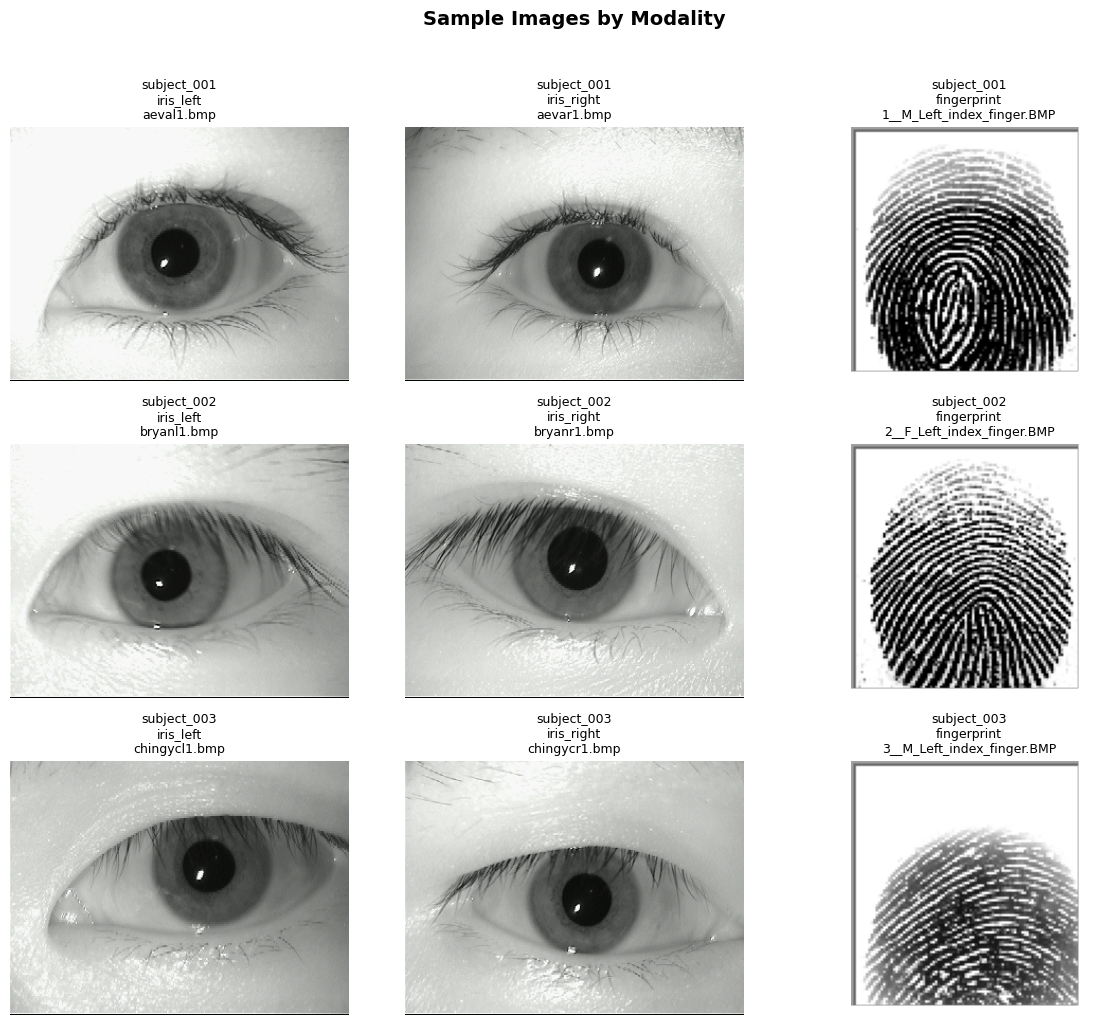

In [3]:
fig, axes = plt.subplots(3, 3, figsize=(12, 10))

sample_subjects = subjects[:3]

for row, subj in enumerate(sample_subjects):
    for col, mod in enumerate(MODALITIES):
        ax = axes[row, col]
        mod_dir = RAW_DIR / subj / mod
        imgs = sorted(mod_dir.iterdir())
        if imgs:
            img = mpimg.imread(str(imgs[0]))
            ax.imshow(img, cmap="gray" if img.ndim == 2 else None)
            ax.set_title(f"{subj}\n{mod}\n{imgs[0].name}", fontsize=9)
        else:
            ax.text(0.5, 0.5, "Missing", ha="center", va="center")
            ax.set_title(f"{subj}\n{mod}", fontsize=9)
        ax.axis("off")

fig.suptitle("Sample Images by Modality", fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

## 3. Class (Subject) Distribution

How many images does each subject have? This tells us if the dataset is balanced.

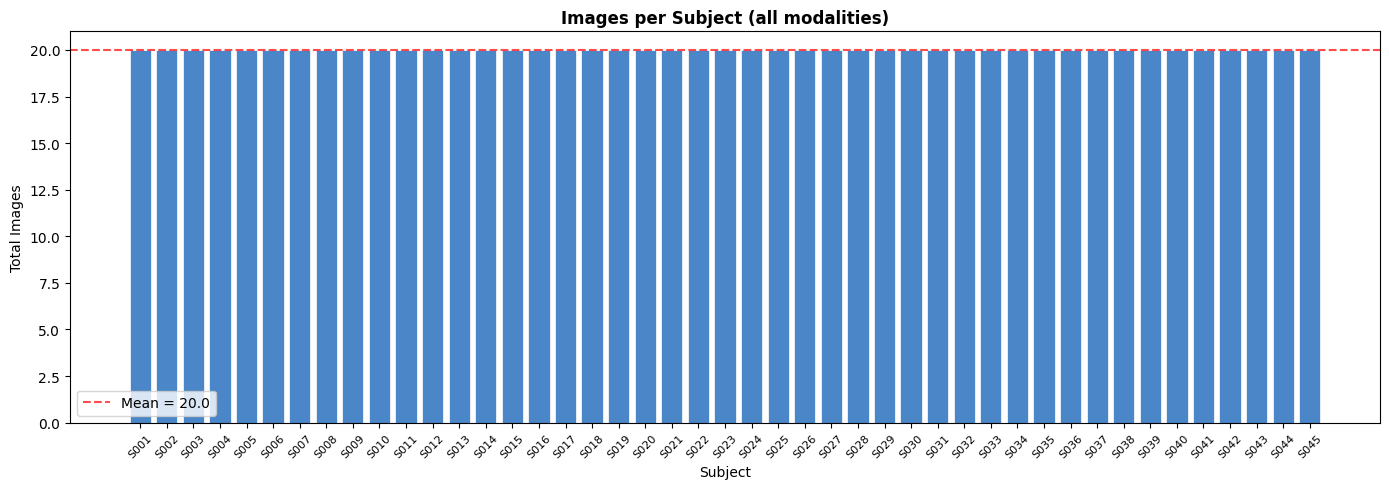

Min images per subject: 20
Max images per subject: 20
Mean: 20.0, Std: 0.0


In [4]:
# Total images per subject (all modalities combined)
imgs_per_subject = {subj: sum(stats[subj].values()) for subj in subjects}

fig, ax = plt.subplots(figsize=(14, 5))
bars = ax.bar(range(len(subjects)), [imgs_per_subject[s] for s in subjects],
              color="#4a86c8", edgecolor="white", linewidth=0.5)
ax.set_xticks(range(len(subjects)))
ax.set_xticklabels([s.replace("subject_", "S") for s in subjects], rotation=45, fontsize=8)
ax.set_xlabel("Subject")
ax.set_ylabel("Total Images")
ax.set_title("Images per Subject (all modalities)", fontweight="bold")

# Stats annotation
mean_imgs = np.mean(list(imgs_per_subject.values()))
ax.axhline(mean_imgs, color="red", linestyle="--", alpha=0.7, label=f"Mean = {mean_imgs:.1f}")
ax.legend()

plt.tight_layout()
plt.show()

print(f"Min images per subject: {min(imgs_per_subject.values())}")
print(f"Max images per subject: {max(imgs_per_subject.values())}")
print(f"Mean: {mean_imgs:.1f}, Std: {np.std(list(imgs_per_subject.values())):.1f}")

## 4. Modality Completeness

Do all subjects have all 3 modalities? Are there missing modalities?

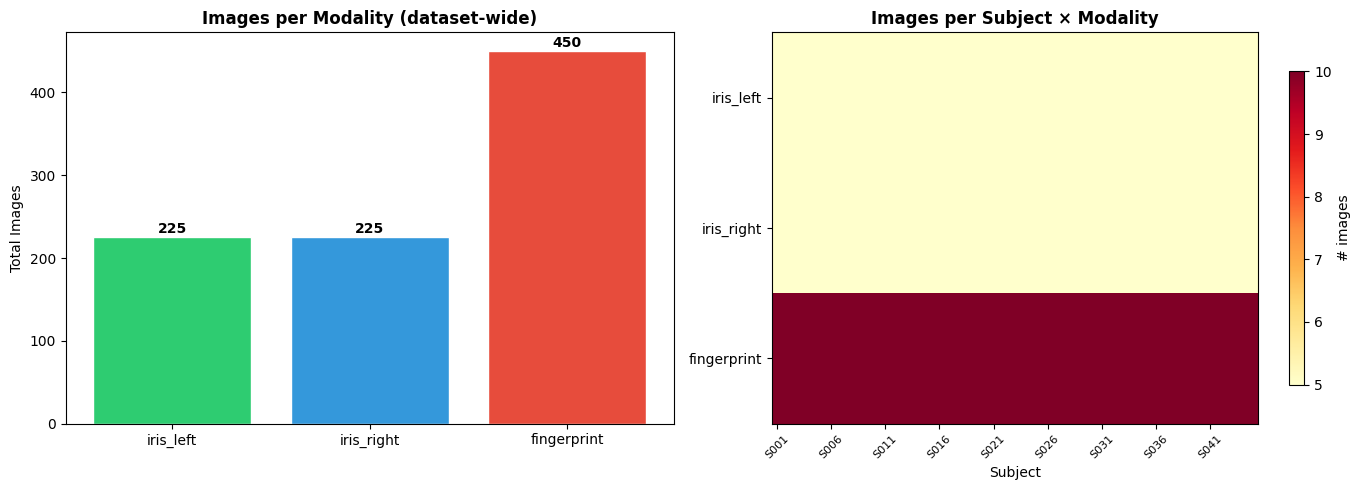


✅ All subjects have all 3 modalities — no missing data.


In [5]:
# Modality-level stats
mod_counts = {mod: [] for mod in MODALITIES}
missing_modalities = []

for subj in subjects:
    for mod in MODALITIES:
        count = stats[subj][mod]
        mod_counts[mod].append(count)
        if count == 0:
            missing_modalities.append((subj, mod))

# Stacked bar chart by modality
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Left: images per modality (aggregated)
mod_totals = {mod: sum(mod_counts[mod]) for mod in MODALITIES}
colors = ["#2ecc71", "#3498db", "#e74c3c"]
ax1.bar(MODALITIES, [mod_totals[m] for m in MODALITIES], color=colors, edgecolor="white")
for i, mod in enumerate(MODALITIES):
    ax1.text(i, mod_totals[mod] + 5, str(mod_totals[mod]), ha="center", fontweight="bold")
ax1.set_ylabel("Total Images")
ax1.set_title("Images per Modality (dataset-wide)", fontweight="bold")

# Right: per-subject modality heatmap
data_matrix = np.array([[stats[s][m] for m in MODALITIES] for s in subjects])
im = ax2.imshow(data_matrix.T, aspect="auto", cmap="YlOrRd", interpolation="nearest")
ax2.set_yticks(range(len(MODALITIES)))
ax2.set_yticklabels(MODALITIES)
ax2.set_xticks(range(0, len(subjects), 5))
ax2.set_xticklabels([subjects[i].replace("subject_", "S") for i in range(0, len(subjects), 5)],
                     rotation=45, fontsize=8)
ax2.set_title("Images per Subject × Modality", fontweight="bold")
ax2.set_xlabel("Subject")
plt.colorbar(im, ax=ax2, shrink=0.8, label="# images")

plt.tight_layout()
plt.show()

if missing_modalities:
    print(f"\n⚠️  Missing modalities ({len(missing_modalities)} cases):")
    for subj, mod in missing_modalities:
        print(f"  {subj}: {mod}")
else:
    print("\n✅ All subjects have all 3 modalities — no missing data.")

## 5. Image Properties

Check raw image dimensions and channel counts across modalities.

In [6]:
from PIL import Image

# Sample a few images per modality to check dimensions
dim_stats = {mod: {"widths": [], "heights": [], "channels": []} for mod in MODALITIES}

for subj in subjects[:10]:  # Sample first 10 subjects
    for mod in MODALITIES:
        mod_dir = RAW_DIR / subj / mod
        if not mod_dir.exists():
            continue
        for img_path in sorted(mod_dir.iterdir())[:2]:  # 2 images per modality
            try:
                with Image.open(img_path) as img:
                    w, h = img.size
                    ch = len(img.getbands())
                    dim_stats[mod]["widths"].append(w)
                    dim_stats[mod]["heights"].append(h)
                    dim_stats[mod]["channels"].append(ch)
            except Exception as e:
                print(f"  Error reading {img_path}: {e}")

print(f"{'Modality':<15} {'Width (min-max)':<18} {'Height (min-max)':<18} {'Channels':<10}")
print("-" * 65)
for mod in MODALITIES:
    ds = dim_stats[mod]
    if ds["widths"]:
        w_range = f"{min(ds['widths'])}-{max(ds['widths'])}"
        h_range = f"{min(ds['heights'])}-{max(ds['heights'])}"
        ch_vals = set(ds["channels"])
        print(f"{mod:<15} {w_range:<18} {h_range:<18} {ch_vals}")
    else:
        print(f"{mod:<15} {'N/A':<18} {'N/A':<18} {'N/A'}")

Modality        Width (min-max)    Height (min-max)   Channels  
-----------------------------------------------------------------
iris_left       320-320            240-240            {3}
iris_right      320-320            240-240            {3}
fingerprint     96-96              103-103            {4}


## 6. Training Split Summary

Our pipeline uses **subject-level splitting** to prevent data leakage. Here's how the splits look.

Subject-level split (seed=42):
  train: 32 subjects, ~620 raw images
    val:  7 subjects, ~140 raw images
   test:  8 subjects, ~140 raw images


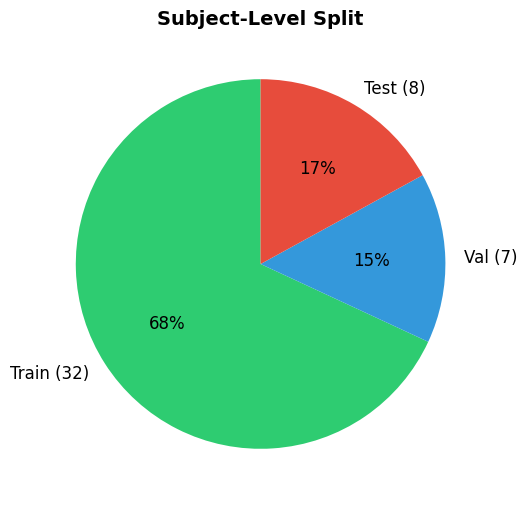

In [7]:
sys.path.insert(0, str(PROJECT_ROOT / "src"))
from biometric.data.dataloader import split_subjects

splits = split_subjects(
    data_dir=str(PROCESSED_DIR),
    train_ratio=0.7,
    val_ratio=0.15,
    seed=42,
)

print("Subject-level split (seed=42):")
for split_name in ("train", "val", "test"):
    subj_list = splits[split_name]
    # Count total samples (images) in this split
    total = sum(sum(stats.get(s, {}).values()) for s in subj_list if s in stats)
    print(f"  {split_name:>5}: {len(subj_list):>2} subjects, ~{total:>3} raw images")

# Pie chart
fig, ax = plt.subplots(figsize=(6, 6))
sizes = [len(splits[s]) for s in ("train", "val", "test")]
labels = [f"Train ({sizes[0]})", f"Val ({sizes[1]})", f"Test ({sizes[2]})"]
colors = ["#2ecc71", "#3498db", "#e74c3c"]
ax.pie(sizes, labels=labels, colors=colors, autopct="%1.0f%%", startangle=90,
       textprops={"fontsize": 12})
ax.set_title("Subject-Level Split", fontweight="bold", fontsize=14)
plt.show()

## Key Takeaways

- **45 subjects**, ~20 images each across 3 modalities (iris left, iris right, fingerprint)
- Dataset is **well-balanced** — every subject has all 3 modalities
- Iris images and fingerprints have different native resolutions → all resized to 224×224 during preprocessing
- **Subject-level splitting** ensures no identity leakage between train/val/test
- Small dataset (~900 images) means overfitting is expected without heavy regularisation — the focus of this project is the **infrastructure**, not model accuracy